# 0. PandasAI Quickstart Guide

This notebook demonstrates how to get started with PandasAI and how to use it to analyze data through natural language.

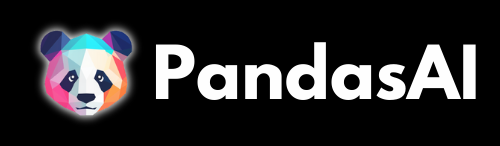


In [54]:
# Importing the required libraries
import pandas as pd
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from IPython.display import Image, display

In [55]:
# Load environment variables
load_dotenv()

True

# 1. Getting Familiar with PandasAI
This section will cover the basics of PandasAI, such as loading data and using the .chat() method to talk to it. 

In later section, we will generate more production ready format for querying raw database tables directly (with semantic enrichment) for better performance. But that is not the focus of this section.

### 1.1: Read Database Directly
For this example, we will load our data directly from our Postgres database using SQLAlquemy 

In [56]:
# Get values from .env
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [57]:
# Create connection to Postgres
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require")

In [58]:
# Connect to Postgres
query = "SELECT * FROM users LIMIT 1000;"

# Load data into pandas
database_df = pd.read_sql(query, engine)
print("Data loaded from Postgres")

database_df.head()

Data loaded from Postgres


,user_id,signup_date,country,device_type
0,1,2024-06-02,Rest,iOS
1,2,2024-03-20,India,Android
2,3,2023-09-17,EU,Web
3,4,2024-02-05,India,iOS
4,5,2025-06-08,India,Web


### 1.2: Set up LLM

Use `pandasai_litellm` to select the LLM of your choice and use PandasAI

In [59]:
# Initialize LiteLLM with an (as an example) open AI model
llm = LiteLLM(model="gpt-4.1-mini")

# Configure PandasAI to use this LLM
pai.config.set({
    "llm": llm
})

### 1.3: Chat with your data
Now we will use the .chat() method to chat with our data

In [60]:
#1.3.1: Convert our normal pandas dataframe to a pandasai dataframe
database_df = pai.DataFrame(database_df)

In [61]:
#1.3.2: Chat with the dataframe (simple table output)
response = database_df.chat("What is the most popular device type per country? Show output as a dataframe")
response.value

,country,most_popular_device,user_count
0,EU,Web,65
1,India,Web,67
2,Rest,iOS,78
3,US,iOS,142


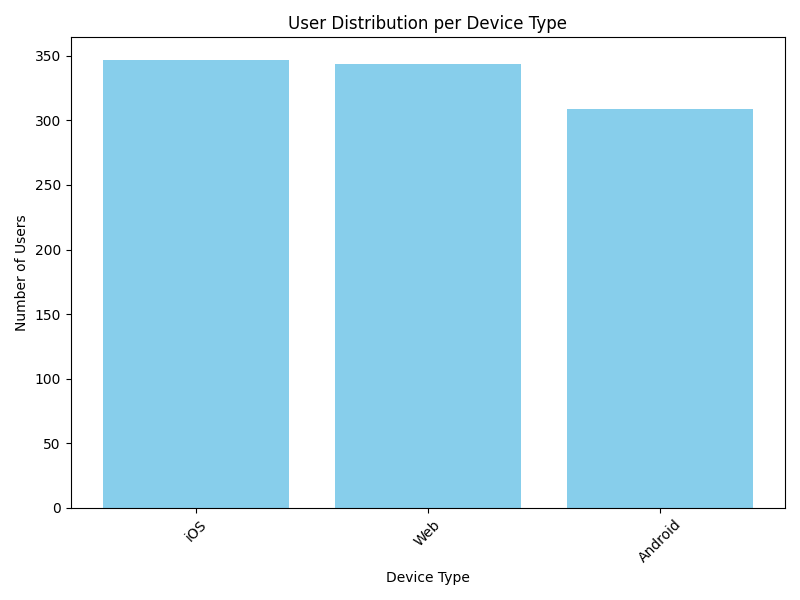

In [62]:
#1.3.3: Simple graphical output
response = database_df.chat("Plot a bar chart showing the distribution of users per device type")

# Extract the path from ChartResponse object
chart_path = response.path if hasattr(response, 'path') else str(response)

# Display the chart with IPython display
display(Image(filename=chart_path, format = 'png'))

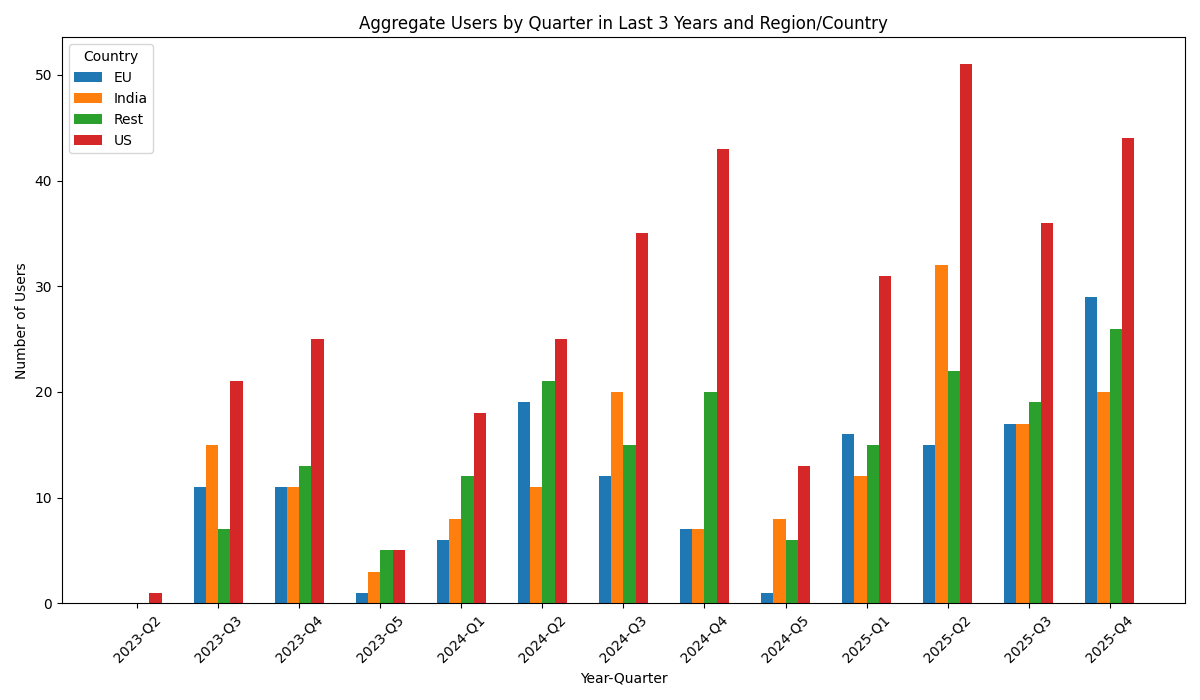

In [64]:
# 1.3.4: Chat with the dataframe (slightly advanced graphical output)
response = database_df.chat(""" Create a bar chart showing aggregate users by quarter in last 3 years and region/country. 
                                Have the X-axis be arranged chronologically
                            """)

# Extract the path from ChartResponse object
chart_path = response.path if hasattr(response, 'path') else str(response)

# Display the chart with IPython display
display(Image(filename=chart_path, format = 'png'))

In [65]:
#.1.3.5a: Chat with your data (Calculated tabular ouput for subsequent analysis)
from IPython.display import Markdown, display

response = database_df.chat(
    """
    Return a table only.

    For each country, calculate total users for:
    - Q1-2025
    - Q2-2025
    - Q3-2025

    Include:
    - country
    - q1_2025_users
    - q2_2025_users
    - q3_2025_users
    - q1_to_q2_change
    - q2_to_q3_change

    Do not provide explanation.
    """
)

response.value

,country,q1_2025_users,q2_2025_users,q3_2025_users,q1_to_q2_change,q2_to_q3_change
0,EU,16,15,17,-1,2
1,India,12,32,17,20,-15
2,Rest,15,22,19,7,-3
3,US,31,51,36,20,-15


In [66]:
#1.3.5b: Chat with your caclualted tabular dataframe from above
from IPython.display import Markdown, display

response = database_df.chat(
    """
    Using the calculated quarter-by-country table, summarize which countries declined in Q2-2025.

    Only describe patterns supported by the table.
    Do not speculate about causes.

    Format the response using markdown headers and bullet points. 
    
    Keep observations concise and quantitative where possible.

    Include:
    ## Summary
    ## Countries with declines 
    ## Countries without meaningful decline
    ## Observed patterns
    """
)

display(Markdown(response.value))


## Summary
- The table includes user signup counts for Q1, Q2, and Q3 in 2025 for each country.
- Change from Q1 to Q2 indicates growth if positive, decline if negative.

## Countries with declines
- EU (declined by -1)

## Countries without meaningful decline
- India (change: 20)
- Rest (change: 7)
- US (change: 20)

## Observed patterns
- Declines in Q2-2025 user counts appear only in the countries listed under declines.
- Other countries show stable or positive change from Q1 to Q2 2025.


# 2. Semantic layers with Pandas AI

Next, we move towards more production oriented formats of accessing data with AI.

Instead of querying raw database tables directly (as above section), we can create semantically enriched datasets using pai.create().  Semantic enrichment allows us to attach: business context, column descriptions, aliases, derived/calculated fields, grouping hints, relationship semantics etc to each dataset before the LLM interacts with the data. 

This approach reduces hallucinated fields, unsupported joins, and ambiguous interpretations. Also, we improve:

- natural language understanding
- analytical grounding
- query interpretation accuracy
- consistency across analytical workflows

#### Creating Semantic Datasets from PostgreSQL

We can persist data from PostgreSQL using the .create() method. This:

- connects to the source database
- creates a reusable local dataset
- stores schema and semantic metadata
- allows datasets to be reloaded later

<u>The `.create()` cells only need to be executed once to initialize datasets and semantic metadata locally. In below example, the `.create()` calls are rendered in markdown format only to avoid reruns. 

Subsequent notebook runs can use `.load()` directly. </u>

*Each dataset acts as a semantic interface between: the raw database schema and the AI analytical layer.*
📚 **[PandasAI Semantic Layer Documentation](https://docs.pandas-ai.com/v3/semantic-layer/new)**

##2.1: Create a reusable dataset for user table based acquisition analysis - do not execute cell if already done in prior nb run
users_dataset = pai.create(

    # Dataset identifier
    path="public/users",

    # Business description used by the LLM
    description="""
    User signup and acquisition dataset.

    Business rules and semantics:
    - Each row represents a unique user.
    - signup_date is the primary date field for signup trend analysis.
    - country represents the user's signup region.
    - device_type represents the signup platform.
    """,

    source={

        # PostgreSQL source configuration
        "type": "postgres",

        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },

        # Source table
        "table": "users",

        # Semantic metadata for columns
        "columns": [

            {
                "name": "user_id",
                "type": "integer",
                "description": "Unique identifier for the user"
            },

            {
                "name": "signup_date",
                "type": "datetime",
                "description": "Date and time when the user signed up"
            },

            {
                "name": "country",
                "type": "string",
                "description": "User country based on signup information",

                # Alternative business terminology
                "alias": "region",

                # Allow grouping operations
                "group_by": True
            },

            {
                "name": "device_type",
                "type": "string",
                "description": "Device type used at signup",

                "alias": "platform",
                "group_by": True
            }
        ]
    }
)

##2.2: Create a reusable dataset for subscription lifecycle analysis - do not execute cell if already done in prior nb run
subscriptions_dataset = pai.create(

    # Dataset identifier
    path="public/subscriptions",

    # Business description used by the LLM
    description="""
    Tracks user subscriptions and subscription lifecycle activity.

    Business rules and semantics:
    - Each row represents a subscription associated with a user.
    - start_date is the primary date field for subscription analysis.
    - end_date supports churn and expiration analysis.
    - status indicates active, canceled, or expired subscriptions.
    """,

    source={

        # PostgreSQL source configuration
        "type": "postgres",

        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },

        # Source table
        "table": "subscriptions",

        # Semantic metadata for columns
        "columns": [

            {
                "name": "subscription_id",
                "type": "integer",
                "description": "Unique identifier for the subscription"
            },

            {
                "name": "user_id",
                "type": "integer",
                "description": "Foreign key linking to the users table"
            },

            {
                "name": "plan",
                "type": "string",
                "description": "Subscription plan (free, monthly, annual)",

                "alias": "subscription_plan",
                "group_by": True
            },

            {
                "name": "start_date",
                "type": "datetime",
                "description": "Date when the subscription started"
            },

            {
                "name": "end_date",
                "type": "datetime",
                "description": "Date when the subscription ended"
            },

            {
                "name": "status",
                "type": "string",
                "description": "Current subscription status",

                "alias": "subscription_status",
                "group_by": True
            },

            {
                # Derived subscription duration metric
                "name": "subscription_length_days",

                "type": "integer",

                "description": "Length of subscription in days",

                "expression": "EXTRACT(DAY FROM (COALESCE(end_date, CURRENT_DATE) - start_date))"
            }
        ]
    }
)

##2.3: Create a reusable dataset for engagement analysis - do not execute cell if already done in prior nb run
sessions_dataset = pai.create(

    # Dataset identifier
    path="public/sessions",

    # Business description used by the LLM
    description="""
    User engagement and activity session dataset.

    Business rules and semantics:
    - Each row represents a user session.
    - session_date is the primary date field for engagement analysis.
    - duration_minutes represents total session duration.
    - activity_type categorizes the session activity.
    """,

    source={

        # PostgreSQL source configuration
        "type": "postgres",

        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },

        # Source table
        "table": "sessions",

        # Semantic metadata for columns
        "columns": [

            {
                "name": "session_id",
                "type": "integer",
                "description": "Unique identifier for the session"
            },

            {
                "name": "user_id",
                "type": "integer",
                "description": "Foreign key linking to the users table"
            },

            {
                "name": "session_date",
                "type": "datetime",
                "description": "Date and time when the session occurred"
            },

            {
                "name": "duration_minutes",
                "type": "integer",
                "description": "Duration of the session in minutes"
            },

            {
                # Derived session duration metric
                "name": "session_hours",

                "type": "number",

                "description": "Session duration expressed in hours",

                "expression": "duration_minutes / 60.0"
            },

            {
                "name": "activity_type",
                "type": "string",
                "description": "Type of activity performed during the session",

                "alias": "engagement_type",
                "group_by": True
            }
        ]
    }
)

##2.4: Create a reusable dataset for revenue and payment analysis - do not execute cell if already done in prior nb run
payments_dataset = pai.create(

    # Dataset identifier
    path="public/payments",

    # Business description used by the LLM
    description="""
    Subscription payment and revenue transaction dataset.

    Business rules and semantics:
    - Each row represents a payment transaction.
    - payment_date is the primary date field for revenue analysis.
    - amount_usd represents payment value in USD.
    - method represents the payment method used.
    """,

    source={

        # PostgreSQL source configuration
        "type": "postgres",

        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },

        # Source table
        "table": "payments",

        # Semantic metadata for columns
        "columns": [

            {
                "name": "payment_id",
                "type": "integer",
                "description": "Unique identifier for the payment"
            },

            {
                "name": "subscription_id",
                "type": "integer",
                "description": "Foreign key linking to the subscriptions table"
            },

            {
                "name": "payment_date",
                "type": "datetime",
                "description": "Date when the payment was made"
            },

            {
                "name": "amount_usd",
                "type": "number",
                "description": "Payment amount in USD",

                # Business-friendly revenue terminology
                "alias": "revenue"
            },

            {
                "name": "method",
                "type": "string",
                "description": "Payment method used",

                "alias": "payment_method",
                "group_by": True
            }
        ]
    }
)

In [67]:
## 2.5: Load datasets stored previously by .create() calls - if notebook is being rerun - for downstream cells

# Load users dataset
users_dataset = pai.load("public/users")

# Load sessions dataset
sessions_dataset = pai.load("public/sessions")

# Load subscriptions dataset
subscriptions_dataset = pai.load("public/subscriptions")

# Load payments dataset
payments_dataset = pai.load("public/payments")

Dataset loaded successfully.
Dataset loaded successfully.
Dataset loaded successfully.
Dataset loaded successfully.


# 3. Semantic layer validation/testing

The following examples validate that the semantic layer behaves as expected across single vs multiple datasets using natural language analytics, semantic joins, derived metrics, temporal aggregation, and visuals generation.

In [68]:
#3.1a: Test alias + grouping behavior - generate df output
response = users_dataset.chat(
    """
    Show signup counts grouped by region and platform.

    Return a clean summary table ordered by highest signup counts.
    """
)

display(response.value)

,region,platform,signup_count
0,US,iOS,2723
1,US,Web,2683
2,US,Android,2673
3,India,Web,1354
4,Rest,Web,1348
5,EU,Web,1344
6,EU,iOS,1328
7,EU,Android,1317
8,Rest,Android,1315
9,India,Android,1310


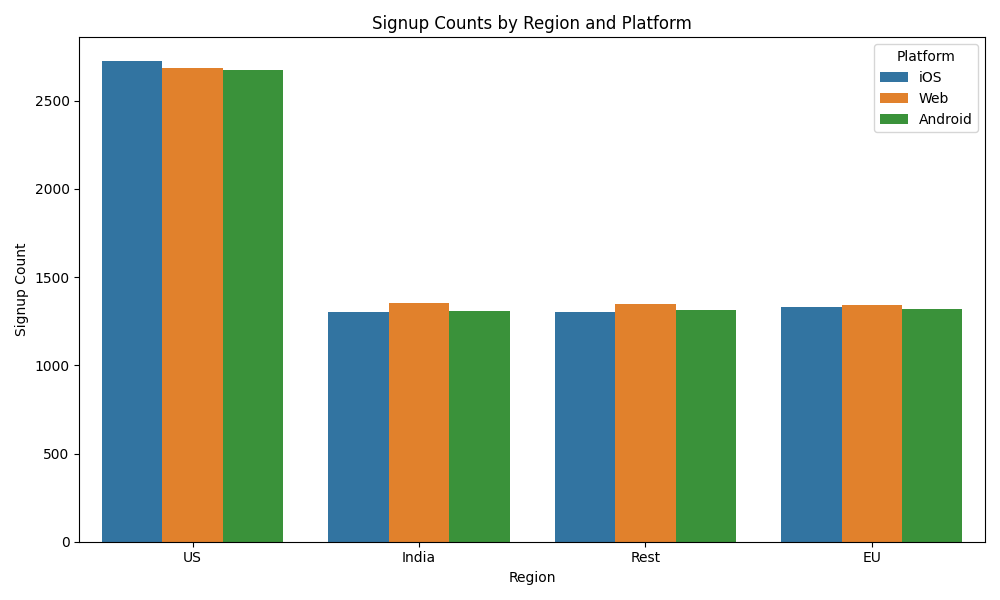

In [69]:
#3.1b: Test alias + grouping behavior - generate visual output
response = users_dataset.chat(
    """
    Create a bar chart showing signup counts by region and platform.
    """
)

chart_path = response.value if hasattr(response, "value") else response.path

display(Image(filename=chart_path, format="png"))

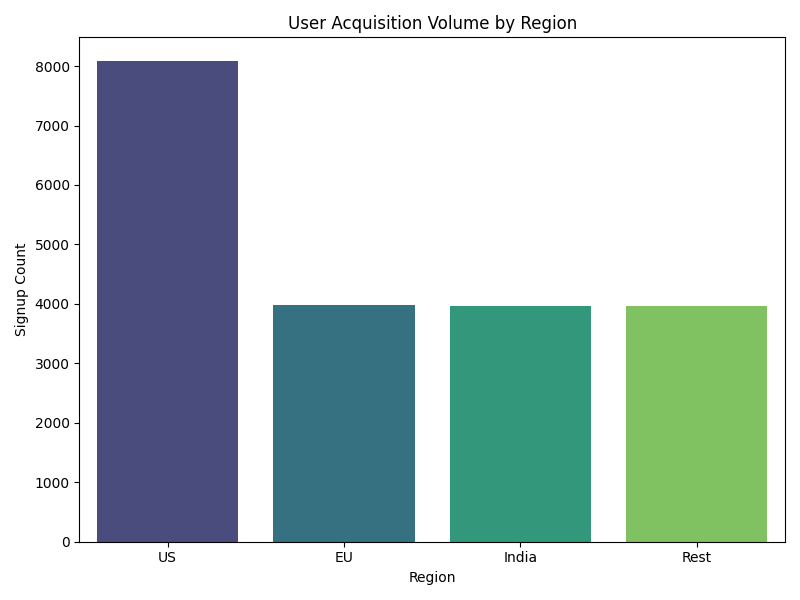

In [70]:
# 3.2: Alias / synonym recognition

response = users_dataset.chat(
    """
    Create a bar chart showing user acquisition volume by region.
    """
)

display(Image(filename=response.value, format="png"))

c:\Users\Owner\AppData\Local\pypoetry\Cache\virtualenvs\pandasai-introduction-eltpA3N6-py3.11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Owner\AppData\Local\pypoetry\Cache\virtualenvs\pandasai-introduction-eltpA3N6-py3.11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


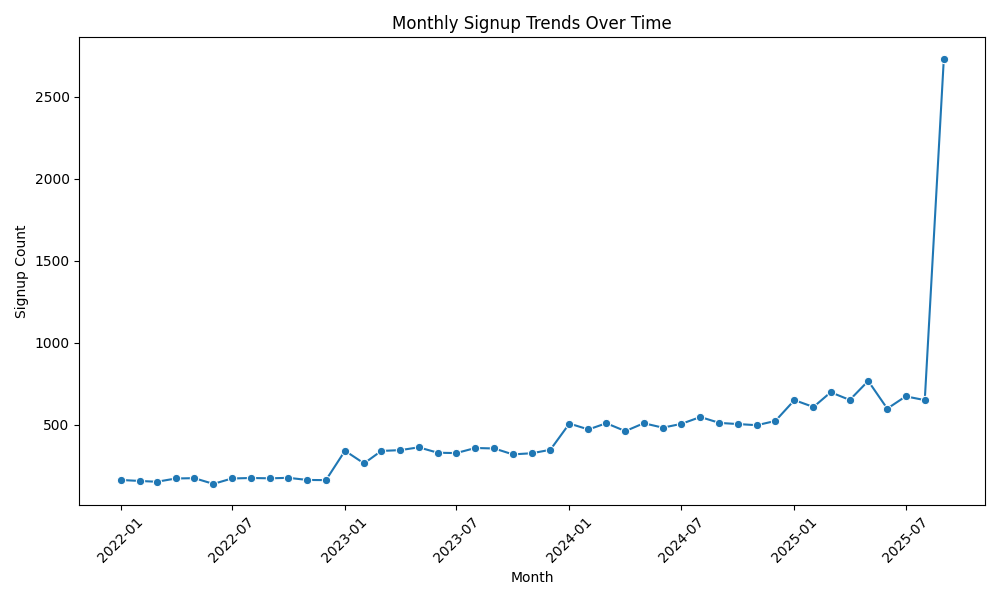

In [71]:
# 3.3: Temporal grouping behavior

response = users_dataset.chat(
    """
    Create a line chart showing monthly signup trends over time.
    """
)

display(Image(filename=response.value, format="png"))

** Multi-dataset semantic agent initialization for complex queries **

In [72]:
# Initialize a shared multi-dataset semantic agent
# to enable cross-table reasoning, semantic joins,
# derived metric handling, and business-context-aware
# natural language analytics across users, subscriptions,
# sessions, and payments datasets.

from pandasai import Agent

agent = Agent([
    users_dataset,
    subscriptions_dataset,
    sessions_dataset,
    payments_dataset
])

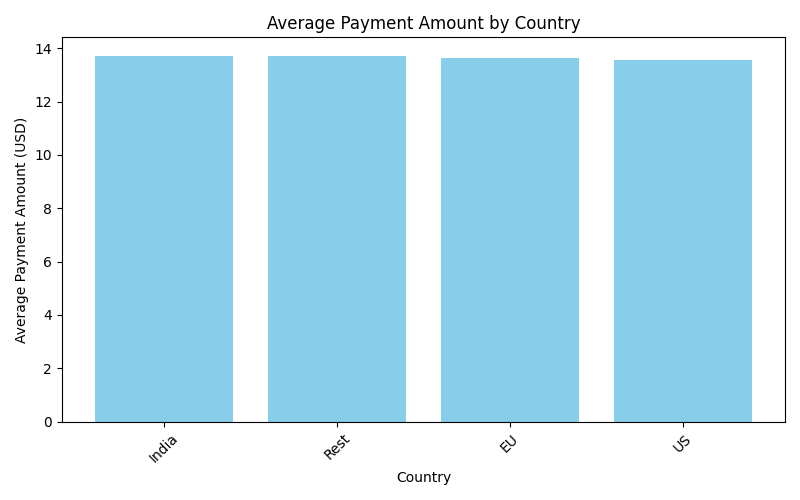

In [73]:
#3.4. Derived metric handling with multi-hop semantic joins
# Tests whether the semantic layer can:
# - resolve business-friendly terminology ("payment amount")
# - traverse relationships across payments -> subscriptions -> users
# - aggregate revenue metrics by geographic dimensions in the users table
# - generate analytical visualizations from natural language queries

response = agent.chat(
    """
    Create a bar chart showing average payment amount by country.
    """
)

display(Image(filename=response.value, format="png"))

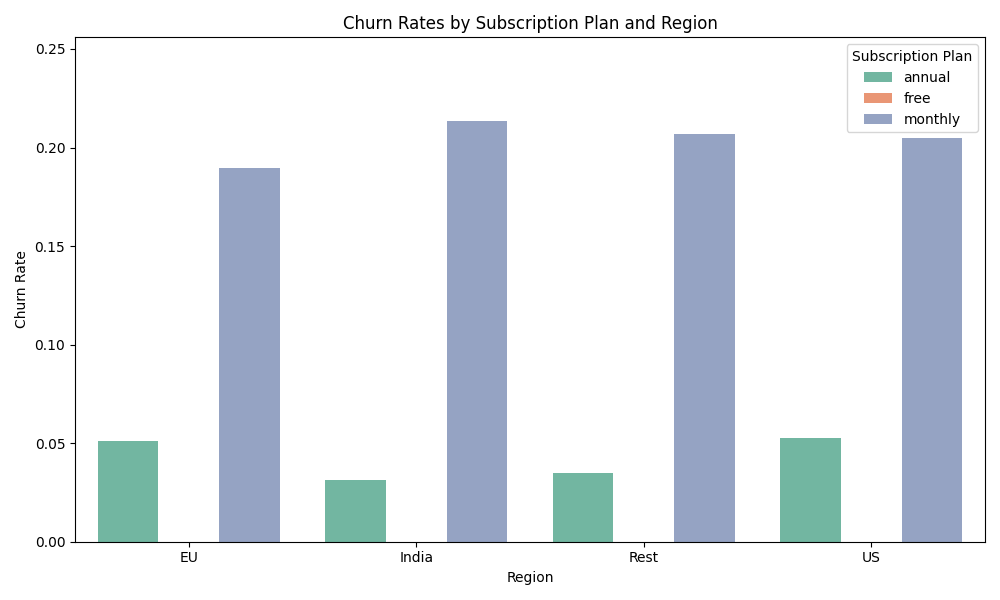

In [ ]:
# 3.5: Analytical interpretation with semantic joins
# Tests whether the agent can:
# - interpret higher-level business concepts such as churn
# - traverse semantic relationships across subscriptions -> users
# - resolve business aliases ("region", "subscription plan")
# - generate comparative analytical visualizations from natural language queries
# - appropriately scale visual output for small metric differences


response = agent.chat(
    """
    Create a bar chart showing churn rates by subscription plan and region.

    Use an appropriate y-axis scale for comparing small churn rate differences.
    """
)

display(Image(filename=response.value, format="png"))

c:\Users\Owner\AppData\Local\pypoetry\Cache\virtualenvs\pandasai-introduction-eltpA3N6-py3.11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Owner\AppData\Local\pypoetry\Cache\virtualenvs\pandasai-introduction-eltpA3N6-py3.11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Owner\AppData\Local\pypoetry\Cache\virtualenvs\pandasai-introduction-eltpA3N6-py3.11\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warn

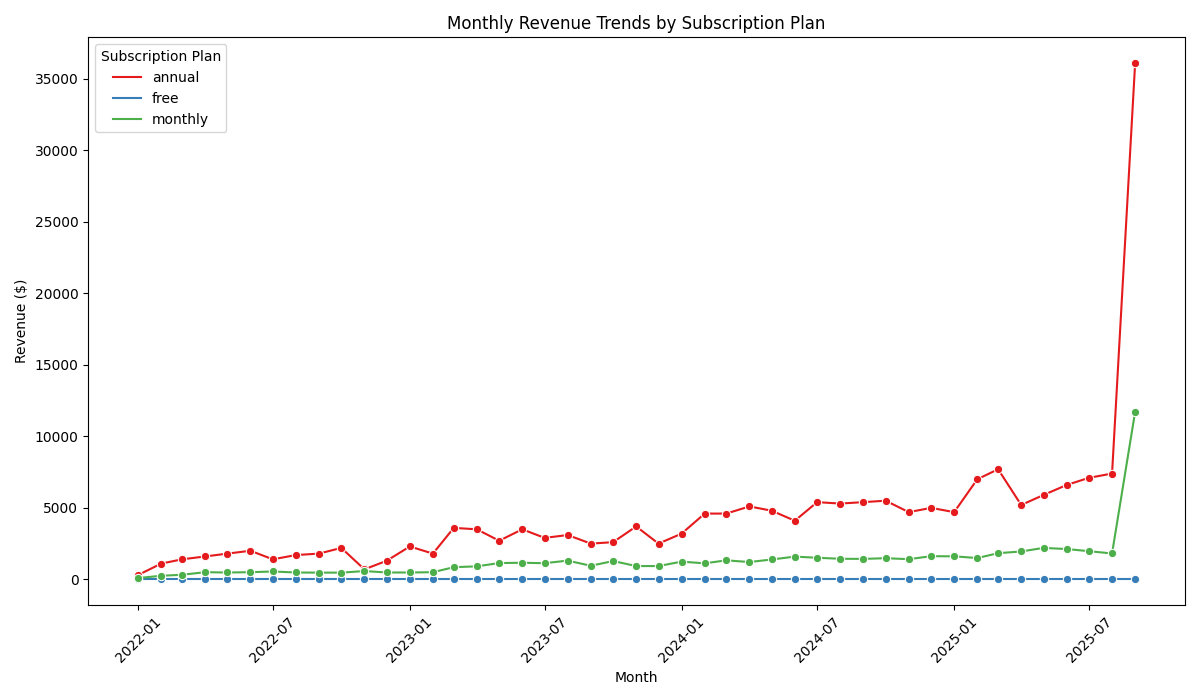

In [75]:
# 3.6: Multi-hop temporal join and cross-table reasoning
# Tests whether the agent can:
# - traverse semantic relationships across payments -> subscriptions
# - resolve business-friendly revenue terminology
# - apply temporal aggregation using payment_date semantics
# - group trends by subscription plan
# - generate time-series analytical visualizations from natural language queries

response = agent.chat(
    """
    Create a line chart showing monthly revenue trends by subscription plan.
    """
)

display(Image(filename=response.value, format="png"))

## Summary

The semantic layer improved analytical querying by enabling alias resolution, temporal aggregation, derived metrics, and business-context-aware querying across multiple datasets.

More advanced cross-table reasoning required explicit multi-dataset agent initialization and semantic relationship configuration for reliable join traversal across related datasets.

### TLDR

This workflow demonstrates how semantic layers and conversational analytics can support broader AI systems. PandasAI could serve as the analytics engine behind tools such as Slackbot-style assistants, allowing users to interrogate business data using natural language across multiple datasets.